In [19]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
import prince
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')

discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])
iris_binned_df['species'] = iris['species']

print(iris_binned_df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           1.0          3.0           0.0          0.0  setosa
1           0.0          2.0           0.0          0.0  setosa
2           0.0          2.0           0.0          0.0  setosa
3           0.0          2.0           0.0          0.0  setosa
4           0.0          3.0           0.0          0.0  setosa


In [2]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [16]:
contingency_table = pd.crosstab(
    [iris_binned_df['sepal_length'], iris_binned_df['sepal_width'],
     iris_binned_df['petal_length'], iris_binned_df['petal_width']],
    iris_binned_df['species']
)

print(contingency_table)


species                                            setosa  versicolor  \
sepal_length sepal_width petal_length petal_width                       
0.0          0.0         0.0          0.0               1           0   
                         1.0          1.0               0           2   
                         2.0          1.0               0           1   
             1.0         0.0          0.0               1           0   
                         2.0          3.0               0           0   
             2.0         0.0          0.0              21           0   
             3.0         0.0          0.0               4           0   
                                      1.0               1           0   
1.0          0.0         2.0          1.0               0           1   
                                      2.0               0           2   
             1.0         1.0          2.0               0           1   
                         2.0          1.0          

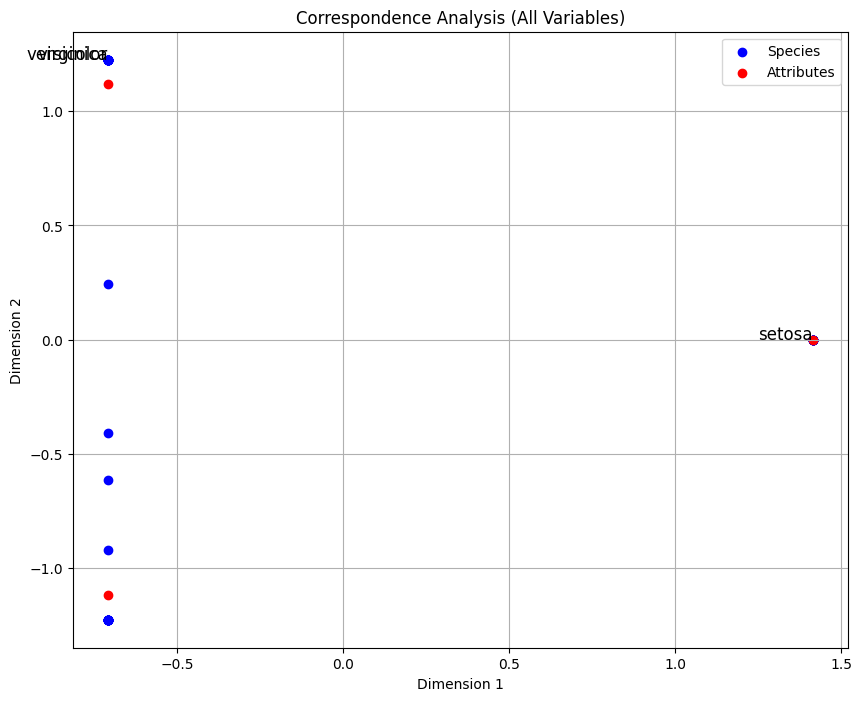

In [23]:
import pandas as pd
import seaborn as sns
import prince
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt
import numpy as np

# Iris 데이터 로드
iris = sns.load_dataset('iris')

# KBinsDiscretizer를 사용하여 모든 특성 이산화 (5개의 구간)
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

# 이산화된 데이터프레임 생성
iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])

# species를 원래대로 추가
iris_binned_df['species'] = iris['species']

# 교차표 생성 (모든 변수들 간의 관계 분석)
contingency_table = pd.crosstab(
    [iris_binned_df['sepal_length'], iris_binned_df['sepal_width'],
     iris_binned_df['petal_length'], iris_binned_df['petal_width']],
    iris_binned_df['species']
)

# 교차표의 데이터 타입이 수치형이어야 하므로 int로 변환
contingency_table = contingency_table.astype(int)

# 대응분석 수행
ca = prince.CA(n_components=2)
ca = ca.fit(contingency_table)

# 결과 (행과 열 좌표)
row_coords = ca.row_coordinates(contingency_table)
col_coords = ca.column_coordinates(contingency_table)

# 행과 열 좌표가 numpy 배열인지 확인 후 float 형으로 변환
row_coords = np.array(row_coords)
col_coords = np.array(col_coords)

# 시각화
plt.figure(figsize=(10, 8))

# species (행 좌표) 시각화
plt.scatter(row_coords[:, 0], row_coords[:, 1], color='blue', label='Species')

# sepal_length, sepal_width, petal_length, petal_width (열 좌표) 시각화
plt.scatter(col_coords[:, 0], col_coords[:, 1], color='red', label='Attributes')

# species 이름 추가
for i, species in enumerate(contingency_table.columns):
    plt.text(row_coords[i, 0], row_coords[i, 1], species, fontsize=12, ha='right')

# 제목 및 축 레이블
plt.title('Correspondence Analysis (All Variables)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\compro\AppData\Local\Temp\ipykernel_16260\532755424.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(row_coords[0][i], row_coords[1][i], species, fontsize=12, ha='right')


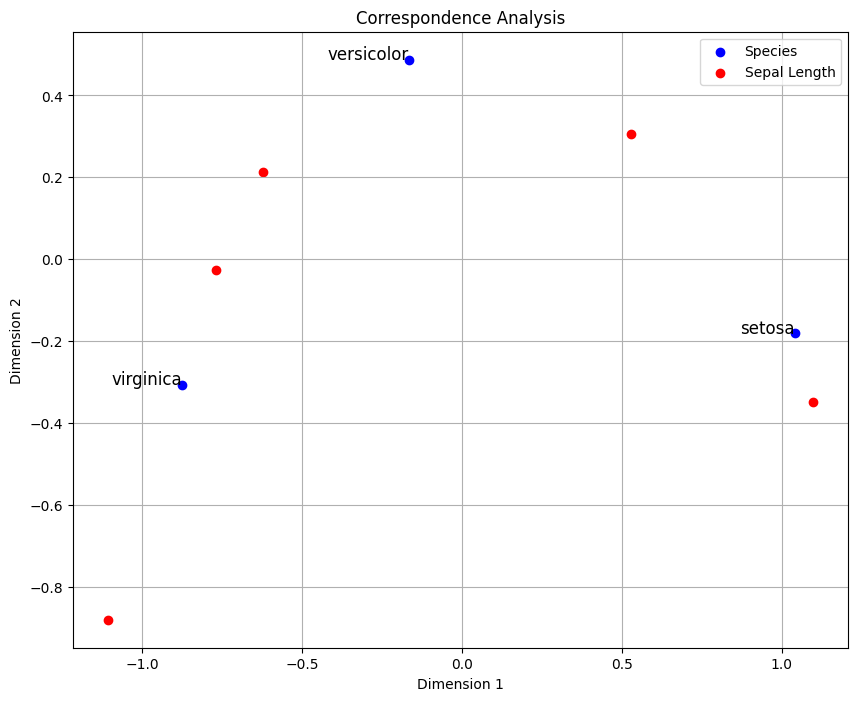

In [7]:
import prince
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Iris 데이터 로드
iris = sns.load_dataset('iris')

from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])
iris_binned_df['species'] = iris['species']

contingency_table = pd.crosstab(index=iris_binned_df['species'], 
                                columns=iris_binned_df['sepal_length'])

ca = prince.CA(n_components=2)
ca = ca.fit(contingency_table)

row_coords = ca.row_coordinates(contingency_table)
col_coords = ca.column_coordinates(contingency_table)

plt.figure(figsize=(10, 8))
plt.scatter(row_coords[0], row_coords[1], color='blue', label='Species')
plt.scatter(col_coords[0], col_coords[1], color='red', label='Sepal Length')

for i, species in enumerate(contingency_table.index):
    plt.text(row_coords[0][i], row_coords[1][i], species, fontsize=12, ha='right')

plt.title('Correspondence Analysis')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])
iris_binned_df['species'] = iris['species']

contingency_table = pd.crosstab(index=iris_binned_df['species'], 
                                columns=iris_binned_df['sepal_length'])

ca = prince.CA(n_components=2)
ca = ca.fit(contingency_table)

row_coords = ca.row_coordinates(contingency_table)
col_coords = ca.column_coordinates(contingency_table)

print("Species 좌표값:")
print(row_coords)
print("\nSepal Length 좌표값:")
print(col_coords)

Species 좌표값:
                   0         1
species                       
setosa      1.041294 -0.180279
versicolor -0.166067  0.487208
virginica  -0.875228 -0.306929

Sepal Length 좌표값:
                     0         1
sepal_length                    
0.0           1.097365 -0.349230
1.0           0.528002  0.305959
2.0          -0.621731  0.213129
3.0          -0.770106 -0.026201
4.0          -1.106231 -0.881052


In [15]:
import pandas as pd
import seaborn as sns
import prince
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt
import numpy as np

# Iris 데이터 로드
iris = sns.load_dataset('iris')

# KBinsDiscretizer를 사용하여 모든 특성 이산화 (5개의 구간)
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

# 이산화된 데이터프레임 생성
iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])

# species를 원래대로 추가
iris_binned_df['species'] = iris['species']

# 교차표 생성 (모든 변수들 간의 관계 분석)
contingency_table = pd.crosstab(
    [iris_binned_df['sepal_length'], iris_binned_df['sepal_width'],
     iris_binned_df['petal_length'], iris_binned_df['petal_width']],
    iris_binned_df['species']
)

# 교차표의 데이터 타입이 수치형이어야 하므로 int로 변환
contingency_table = contingency_table.astype(int)

# 대응분석 수행
ca = prince.CA(n_components=2)
ca = ca.fit(contingency_table)

# 결과 (행과 열 좌표)
row_coords = ca.row_coordinates(contingency_table)
col_coords = ca.column_coordinates(contingency_table)

# numpy 배열을 float 형으로 변환
row_coords = row_coords.astype(float)
col_coords = col_coords.astype(float)

# 시각화
plt.figure(figsize=(10, 8))

# species (행 좌표) 시각화
plt.scatter(row_coords[0], row_coords[1], color='blue', label='Species')

# sepal_length, sepal_width, petal_length, petal_width (열 좌표) 시각화
plt.scatter(col_coords[0], col_coords[1], color='red', label='Attributes')

# species 이름 추가
for i, species in enumerate(contingency_table.columns):
    plt.text(row_coords[0][i], row_coords[1][i], species, fontsize=12, ha='right')

# 제목 및 축 레이블
plt.title('Correspondence Analysis (All Variables)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid(True)
plt.show()

TypeError: cannot convert the series to <class 'float'>

<Figure size 1000x800 with 1 Axes>